In [1]:
from pathlib import Path 

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox


In [39]:
from adjustText import adjust_text

In [2]:
print(Path.cwd())

d:\Wu\2026\Project Portfolio\002 Project\grocery_stores_access\notebooks


In [3]:
PROCESSED_DIR = Path("../data/processed")

In [4]:
county_boundary = gpd.read_file(PROCESSED_DIR / "county_boundary.gpkg")
stores = gpd.read_file(PROCESSED_DIR / "grocery_store_nodes.gpkg")
G = ox.load_graphml(PROCESSED_DIR / "kootenai_drive.graphml")

In [5]:
nodes, edges = ox.graph_to_gdfs(G)
roads = edges

In [6]:
cities = gpd.read_file(PROCESSED_DIR / "kootenai_cities.gpkg")

In [36]:
cities

,STATEFP,PLACEFP,PLACENS,GEOIDFQ,GEOID,city,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,16,17830,02585569,1600000US1617830,1617830,Conkling Park,Conkling Park CDP,ID,Idaho,57,2705973,0,"MULTIPOLYGON (((-116.77444 47.40424, -116.7680..."
1,16,88480,02412309,1600000US1688480,1688480,Worley,Worley city,ID,Idaho,25,502488,0,"MULTIPOLYGON (((-116.92204 47.40602, -116.9168..."
2,16,35200,02410708,1600000US1635200,1635200,Harrison,Harrison city,ID,Idaho,25,9231198,2176062,"MULTIPOLYGON (((-116.76661 47.46814, -116.7656..."
3,16,68950,02585592,1600000US1668950,1668950,Rockford Bay,Rockford Bay CDP,ID,Idaho,57,9778278,0,"MULTIPOLYGON (((-116.91344 47.50966, -116.9146..."
4,16,27550,02410496,1600000US1627550,1627550,Fernan Lake Village,Fernan Lake Village city,ID,Idaho,25,197627,2689,"MULTIPOLYGON (((-116.75086 47.67167, -116.7487..."
5,16,16750,02410187,1600000US1616750,1616750,Coeur d'Alene,Coeur d'Alene city,ID,Idaho,25,43691994,1976736,"MULTIPOLYGON (((-116.85096 47.70088, -116.8509..."
6,16,39070,02410802,1600000US1639070,1639070,Huetter,Huetter city,ID,Idaho,25,117471,0,"MULTIPOLYGON (((-116.85161 47.70503, -116.8509..."
7,16,77050,02411974,1600000US1677050,1677050,State Line,State Line city,ID,Idaho,25,285215,0,"MULTIPOLYGON (((-117.03937 47.70445, -117.0390..."
8,16,64810,02411475,1600000US1664810,1664810,Post Falls,Post Falls city,ID,Idaho,25,49621216,70897,"MULTIPOLYGON (((-116.88626 47.72126, -116.8862..."
9,16,20350,02410289,1600000US1620350,1620350,Dalton Gardens,Dalton Gardens city,ID,Idaho,25,6168849,13365,"MULTIPOLYGON (((-116.78673 47.74058, -116.7867..."


In [7]:
all_service_areas = gpd.read_file(
    PROCESSED_DIR / "grocery_service_areas.gpkg"
)

In [8]:
all_service_areas.head()

,name,city,minutes,geometry
0,Grocery Outlet,Coeur d'Alene,10,"POLYGON ((503268.061 5281532.66, 503190.023 52..."
1,Grocery Outlet,Coeur d'Alene,20,"POLYGON ((498134.235 5278426.094, 498119.326 5..."
2,Grocery Outlet,Coeur d'Alene,30,"POLYGON ((496235.593 5253261.756, 496216.463 5..."
3,Little Town Market,Athol,10,"POLYGON ((512057.612 5309792.183, 512055.879 5..."
4,Little Town Market,Athol,20,"POLYGON ((506809.835 5291444.637, 506738.984 5..."


In [9]:
all_service_areas.shape

(90, 4)

In [10]:
all_service_areas["minutes"].value_counts()

minutes
10    30
20    30
30    30
Name: count, dtype: int64

In [27]:
all_service_areas = all_service_areas.to_crs(roads.crs)
cities = cities.to_crs(roads.crs)
stores = stores.to_crs(roads.crs)
county_boundary = county_boundary.to_crs(roads.crs)

In [28]:
print(roads.crs)
print(all_service_areas.crs)
print(cities.crs)
print(stores.crs)
print(county_boundary.crs)

epsg:4326
epsg:4326
epsg:4326
EPSG:4326
epsg:4326


In [19]:
service10 = all_service_areas[
    all_service_areas["minutes"] == 10
]

In [20]:
service20 = all_service_areas[
    all_service_areas["minutes"] == 20
]

In [21]:
service30 = all_service_areas[
    all_service_areas["minutes"] == 30
]

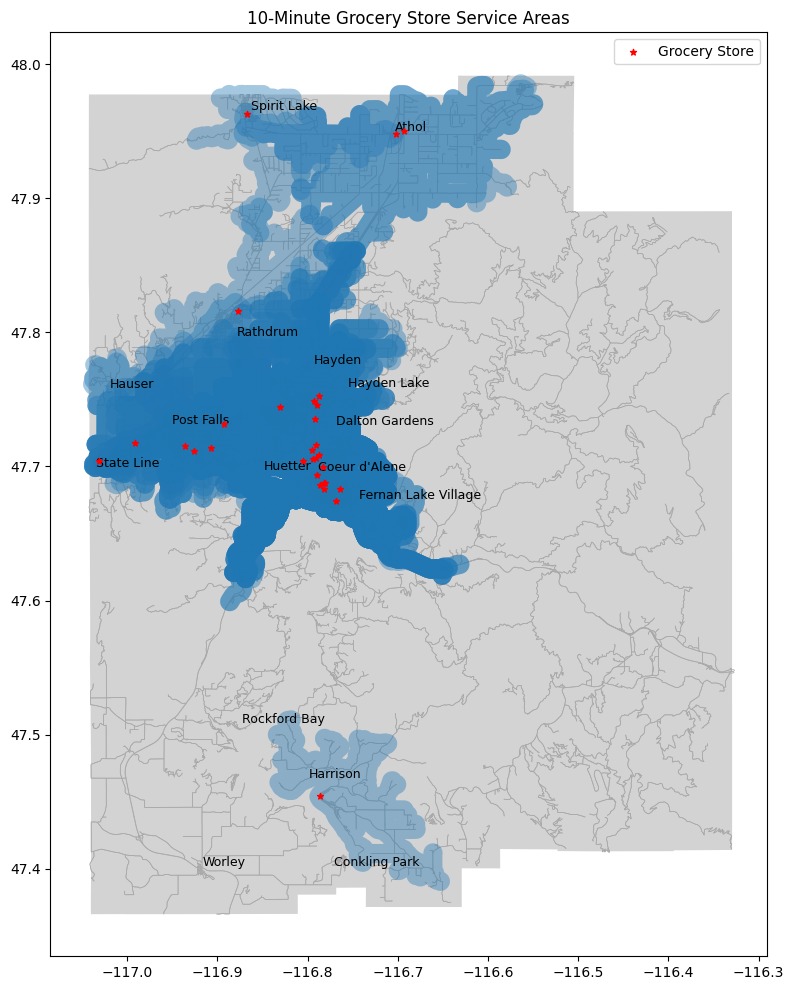

In [48]:
fig, ax = plt.subplots(
    figsize=(12, 12)
)

county_boundary.plot(
    ax=ax,
    linewidth=1,
    color="lightgray",
    zorder=1
)

roads.plot(
    ax=ax,
    linewidth=0.5,
    color="darkgray",
    zorder=2
)


service10.plot(
    ax=ax,
    alpha=0.4,
    zorder=3
)

stores.plot(
    ax=ax,
    marker="*",
    color="red",
    markersize=20,
    label="Grocery Store",
    zorder=4
)

texts = []
for _, row in cities.iterrows():
    label_point = row.geometry.representative_point()

    texts.append(
        ax.text(
            label_point.x,
            label_point.y,
            row["city"],
            fontsize=9
        )
    )

adjust_text(texts)



ax.set_title(
    "10-Minute Grocery Store Service Areas"
)

ax.legend()
plt.show()